# 📞 Telco Customer Churn Dataset - Exploratory Data Analysis (EDA)

## 📌 1. Introduction

### 📖 Project Overview

Customer churn is a key business challenge in the telecommunications industry, as losing existing customers can directly impact a company's growth and revenue. Understanding why customers leave helps businesses improve their services, increase customer satisfaction, and build effective retention strategies.

The **Telco Customer Churn** dataset contains information about customer demographics, subscribed services, account details, billing information, payment methods, and contract types. It also includes the **Churn** column, which indicates whether a customer has left the company or continued using its services.

In this project, an **Exploratory Data Analysis (EDA)** is performed to understand the dataset, identify meaningful patterns, analyze customer behavior, and explore the relationship between different features and customer churn. The insights gained from this analysis can also serve as a strong foundation for building machine learning models to predict customer churn.

---

### 🎯 Objectives of the Analysis

The main objectives of this analysis are:

- To understand the structure and quality of the dataset.
- To perform data cleaning by handling missing values, incorrect data types, and duplicate records.
- To analyze customer demographics, services, billing, and contract information.
- To explore the distribution of different features using visualizations.
- To identify the factors that are associated with customer churn.
- To discover meaningful business insights that can help improve customer retention.
- To prepare the dataset for future machine learning models.

# 2. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. LOAD DATASET

In [2]:
df=pd.read_csv('telco_customer_churn.csv')
pd.set_option('display.max_columns',None)

# 4. DATASET OVERVIEW

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
print(f"No of rows = {df.shape[0]}")
print(f"No of columns = {df.shape[1]}")

No of rows = 7043
No of columns = 21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [8]:
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)

In [9]:
df['TotalCharges']=df['TotalCharges'].astype('float')

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
print(f'No of duplicate values = {df.duplicated().sum()}')

No of duplicate values = 0


# 5. UNIVARIATE ANALYSIS

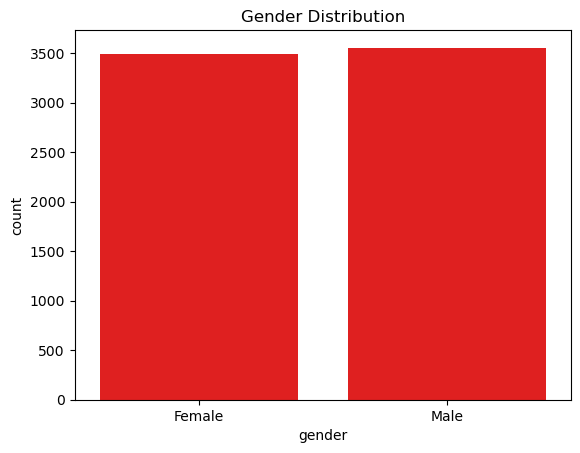

In [12]:
plt.title('Gender Distribution')
sns.countplot(data=df,x='gender',color='red')
plt.show()

In [13]:
print(f"Male Percentage = {(((df['gender']=='Male').sum()*100)/len(df)).round(2)}%")
print(f"Female Percentage = {(((df['gender']=='Female').sum()*100)/len(df)).round(2)}%")

Male Percentage = 50.48%
Female Percentage = 49.52%


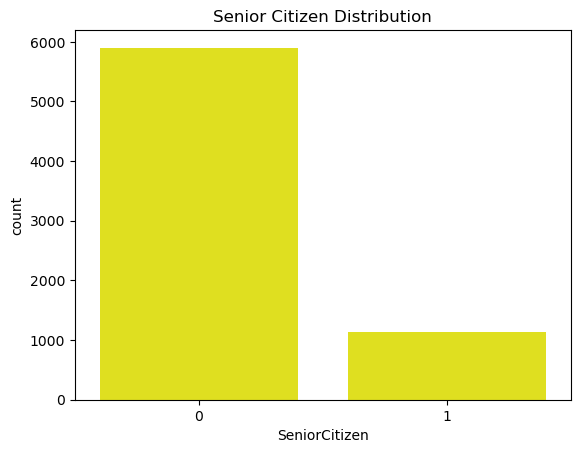

In [14]:
plt.title('Senior Citizen Distribution')
sns.countplot(data=df,x='SeniorCitizen',color='yellow')
plt.show()

In [15]:
print(f'Percentage of Senior Citizens = {((df['SeniorCitizen']==1).sum()*100)/len(df):.2f}%')

Percentage of Senior Citizens = 16.21%


In [16]:
print(f'Percentage of Customer having a partner  = {((df['Partner']=='Yes').sum()*100)/len(df):.2f}%')

Percentage of Customer having a partner  = 48.30%


In [17]:
print(f'Percentage of Dependent Customers= {((df['Dependents']=='Yes').sum()*100)/len(df):.2f}%')

Percentage of Dependent Customers= 29.96%


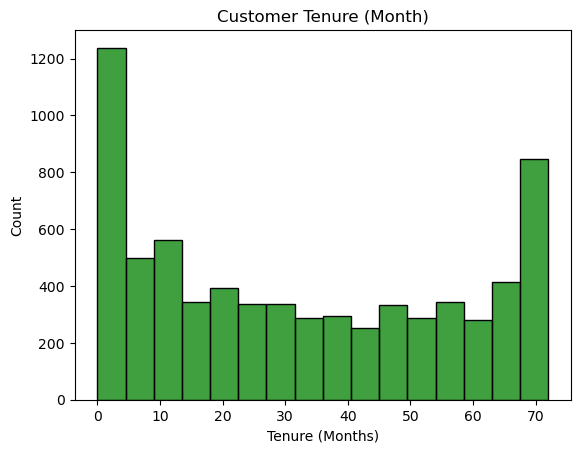

In [18]:
sns.histplot(data=df,x='tenure',color='green')
plt.title('Customer Tenure (Month)')
plt.xlabel('Tenure (Months)')
plt.show()

In [19]:
print(f'Approximately {((df['tenure']>=24).sum()*100)/len(df):.2f}% of customers have a tenure of at least 1 year (24 months)')
print(f'The Longest Customer tenure is of {df['tenure'].max()} months')

Approximately 55.76% of customers have a tenure of at least 1 year (24 months)
The Longest Customer tenure is of 72 months


In [20]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

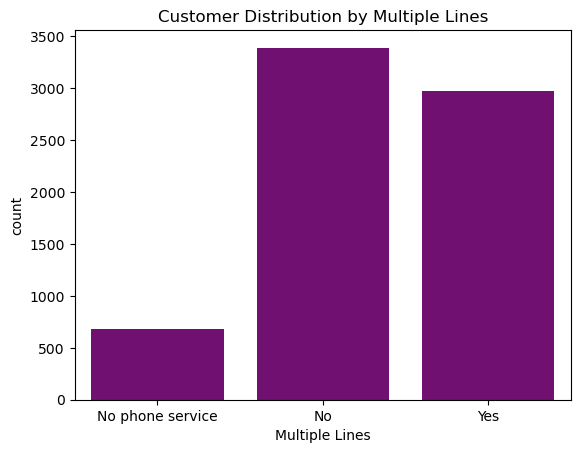

In [21]:
sns.countplot(data=df,x='MultipleLines',color='purple')
plt.xlabel('Multiple Lines')
plt.title('Customer Distribution by Multiple Lines')
plt.show()

In [22]:
print(f"{((df['MultipleLines']=='No phone service').sum()*100)/len(df):.2f}% Customer having No Phone service")
print(f"{((df['MultipleLines']=='No').sum()*100)/len(df):.2f}% Customer having only one phone line")
print(f"{((df['MultipleLines']=='Yes').sum()*100)/len(df):.2f}% Customer having Multiple phone line")

9.68% Customer having No Phone service
48.13% Customer having only one phone line
42.18% Customer having Multiple phone line


In [23]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

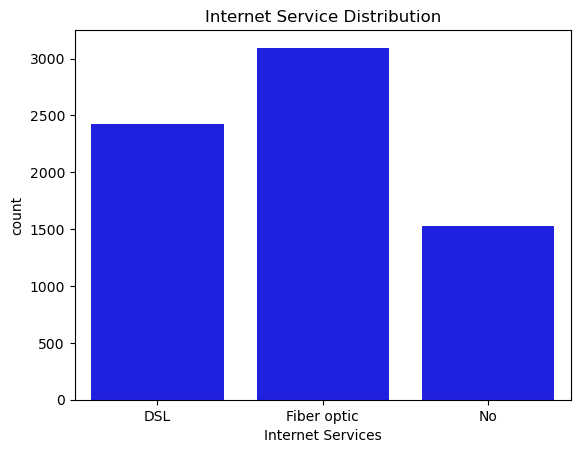

In [24]:
sns.countplot(data=df,x='InternetService',color='Blue')
plt.title('Internet Service Distribution')
plt.xlabel('Internet Services')
plt.show()

In [25]:
print(f'{((df['InternetService']=='No').sum()*100)/len(df):.2f}% of customers has No Intenet Service')
print(f'{((df['InternetService']!='No').sum()*100)/len(df):.2f}% of customer uses Intenet Service')
print(f"{((df['OnlineSecurity']=='Yes').sum()*100)/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to Online Security")

21.67% of customers has No Intenet Service
78.33% of customer uses Intenet Service
36.60% of customers with Internet service have subscribed to Online Security


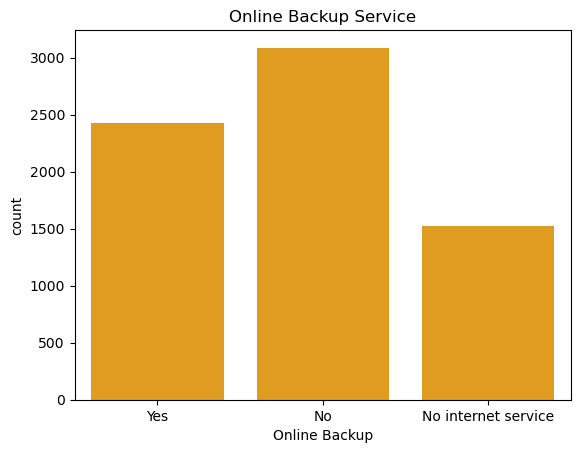

In [26]:
sns.countplot(data=df,x='OnlineBackup',color='orange')
plt.title('Online Backup Service')
plt.xlabel('Online Backup')
plt.show()

In [27]:
print(f"{(df['OnlineBackup']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have Online backup Service")
print(f"Among customers with internet service, {(df['DeviceProtection']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% have opted for the Device Protection Service.")
print(f"{(df['TechSupport']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to the Tech Support service.")
print(f"{(df['StreamingTV']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to the company's TV streaming service.")
print(f"{(df['StreamingMovies']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to the company's movie streaming service.")

44.03% of customers with Internet service have Online backup Service
Among customers with internet service, 43.90% have opted for the Device Protection Service.
37.05% of customers with Internet service have subscribed to the Tech Support service.
49.07% of customers with Internet service have subscribed to the company's TV streaming service.
49.52% of customers with Internet service have subscribed to the company's movie streaming service.


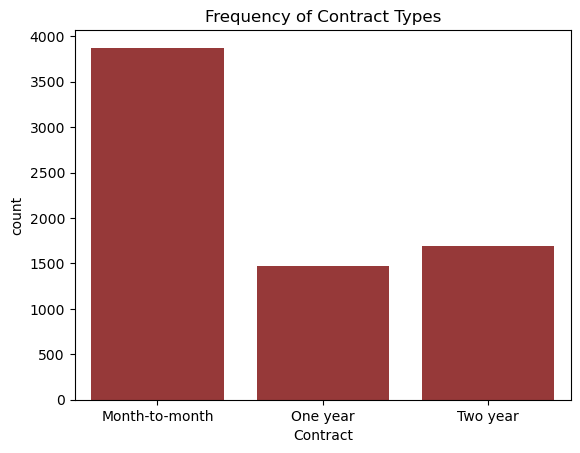

In [28]:
sns.countplot(data=df,x='Contract',color='brown')
plt.title('Frequency of Contract Types')
plt.show()

In [29]:
print(f'{(df['PaperlessBilling']=='Yes').sum()*100/len(df):.2f}% of customers were using Paper less billing')

59.22% of customers were using Paper less billing


In [30]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [31]:
print(f"Most Customer uses the '{df['PaymentMethod'].value_counts().idxmax()}' as their Payment Method")

Most Customer uses the 'Electronic check' as their Payment Method


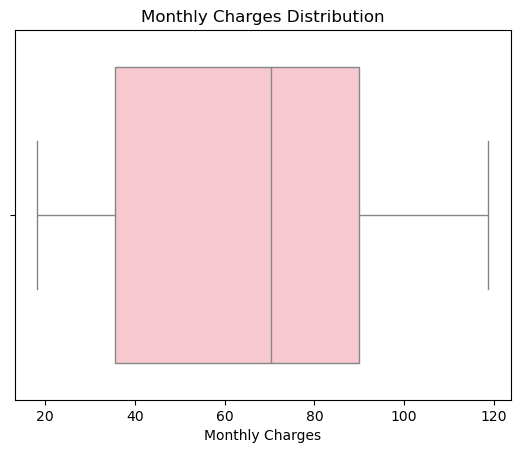

In [32]:
sns.boxplot(data=df,x='MonthlyCharges',color='pink')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.show()

In [33]:
print(f"The average monthly charge per customer is {df['MonthlyCharges'].mean():.2f}")

The average monthly charge per customer is 64.76


In [34]:
print(f"The average total charge per customer is {df['TotalCharges'].mean():.2f}.")

The average total charge per customer is 2283.30.


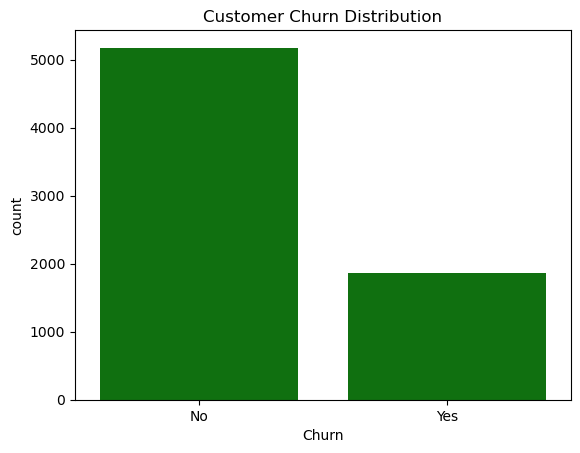

In [35]:
sns.countplot(x=df['Churn'],color='green')
plt.title('Customer Churn Distribution')
plt.show()

In [36]:
print(f"Approximately {(df['Churn']=='No').sum()*100/len(df):.2f}% of customers have stayed with the company.")

Approximately 73.46% of customers have stayed with the company.


# 6. BIVARIATE ANALYSIS

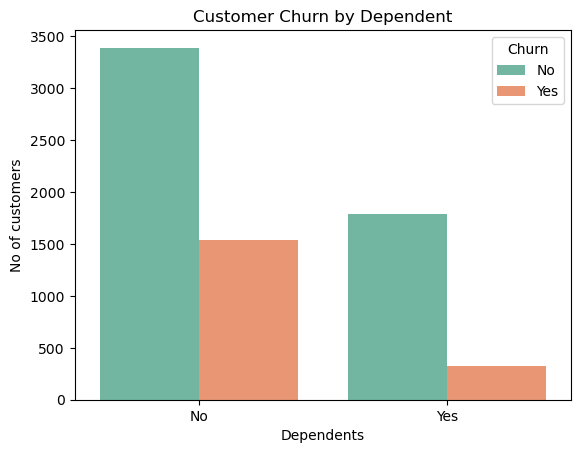

In [37]:
sns.countplot(data=df,x='Dependents',hue='Churn',palette='Set2')
plt.title("Customer Churn by Dependent")
plt.ylabel('No of customers')
plt.show()

In [38]:
print(f"Customer with dependents has lower churn rate with customers without dependents")

Customer with dependents has lower churn rate with customers without dependents


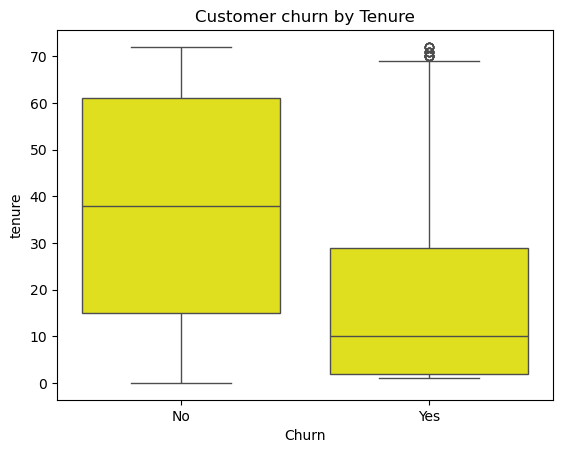

In [39]:
sns.boxplot(data=df,x='Churn',y='tenure',color='yellow')
plt.title('Customer churn by Tenure')
plt.show()

In [40]:
print("Customers with higher tenure are generally less likely to churn.")

Customers with higher tenure are generally less likely to churn.


In [41]:
In_churn=(pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100).round(2)
In_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [42]:
print(f"Customer with Fiber Optic has the highest churn rate [{In_churn.iloc[1,1]}%]")
print(f"Customer with No Internet Service has the lowest churn rate [{In_churn.iloc[2,1]}%]")

Customer with Fiber Optic has the highest churn rate [41.89%]
Customer with No Internet Service has the lowest churn rate [7.4%]


In [43]:
(pd.crosstab(df['OnlineBackup'],df['Churn'],normalize='index')*100).round(2)

Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


In [44]:
print(f"Customer with No Online Backup Service has the more churn rate than the customers with Online Backup Service")

Customer with No Online Backup Service has the more churn rate than the customers with Online Backup Service


In [45]:
contract_churn=(pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100).round(2)
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [46]:
print(f"Customer with Two year of contract has the lowest churn rate {contract_churn.iloc[2,1]}%")
print(f"Customer with Month-to-Month year of contract has the highest churn rate {contract_churn.iloc[0,1]}%")

Customer with Two year of contract has the lowest churn rate 2.83%
Customer with Month-to-Month year of contract has the highest churn rate 42.71%


In [47]:
pay_churn=(pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100).round(2)
pay_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [48]:
print(f"Customer using Electronic check as payment method has the highest churn rate {pay_churn.iloc[2,1]}%")
print(f"Customer using credit card as payment method has the lowest churn rate {pay_churn.iloc[1,1]}%")

Customer using Electronic check as payment method has the highest churn rate 45.29%
Customer using credit card as payment method has the lowest churn rate 15.24%


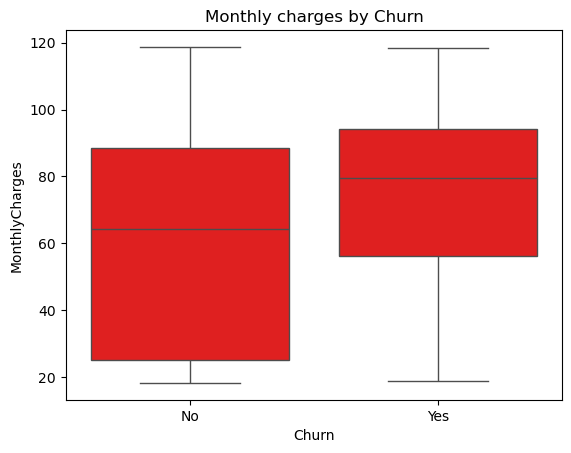

In [49]:
sns.boxplot(data=df,x='Churn',y='MonthlyCharges',color='red')
plt.title('Monthly charges by Churn')
plt.show()

In [50]:
print('Customer who churn has generally have higher monthly charges than customers who stay')

Customer who churn has generally have higher monthly charges than customers who stay


# 8.KEY INSIGHT

- **Most customers** do not have dependents. Customers with **dependents** have a **lower churn rate**.
- **Most customers** have a tenure of around **1 year**, while the **maximum tenure** is **72 months**.
- **Most customers** have a **phone service** with a **single phone line**.
- **Fiber optic** is the **most used** internet service and has the **highest churn rate**.
- **Most customers** with internet service do **not** use **Online Backup**, and they have a **higher churn rate**.
- **Most customers** do **not** subscribe to **Device Protection**, **Tech Support**, **Streaming TV**, or **Streaming Movies**.
- **Month-to-month** is the **most popular** contract type.
- **Most customers** use **Paperless Billing**.
- **Electronic Check** is the **most common** payment method and has the **highest churn rate**.
- Customers with **longer tenure** are **less likely to churn**.
- Customers with **no internet service** have the **lowest churn rate**.
- Customers with a **two-year contract** have the **lowest churn rate** among all contract types.
- Customers with **higher monthly charges** are **more likely to churn** than customers with lower monthly charges.

In [51]:
df=df.drop('customerID',axis=1)

In [52]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [53]:
col=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for i in col:
    df[i]=df[i].map({'Yes':1,'No':0})

In [54]:
df=pd.get_dummies(df,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'],drop_first=True,dtype=int)

In [55]:
df['gender']=df['gender'].map({'Male':0,'Female':1})

In [56]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,0,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,0,0,1
7039,1,0,1,1,72,1,1,103.20,7362.90,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,0,0
7040,1,0,1,1,11,0,1,29.60,346.45,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [57]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train,X_test,y_train,y_test=X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
Scaler=StandardScaler()

In [63]:
X_train=Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

In [190]:
model_1=LogisticRegression(class_weight='balanced')
model_1.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [192]:
y_pred=model_1.predict(X_test)
y_prob = model_1.predict_proba(X_test)[:, 1]
threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)

In [202]:
print("Training score =",model_1.score(X_train,y_train))

Training score = 0.7365409071640525


In [203]:
print("Testing score =",model_1.score(X_test,y_test))

Testing score = 0.7548387096774194


In [193]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [194]:
acc=accuracy_score(y_test,y_pred)

In [195]:
acc

0.7548387096774194

In [196]:
confusion_matrix(y_test,y_pred,labels=[1,0])

array([[ 530,   98],
       [ 472, 1225]])

In [198]:
print("Precision score =",precision_score(y_test,y_pred))
print("Recall score =",recall_score(y_test,y_pred))
print("F1 SCORE =",f1_score(y_test,y_pred))

Precision score = 0.5289421157684631
Recall score = 0.8439490445859873
F1 SCORE = 0.6503067484662577


In [204]:
from sklearn.tree import DecisionTreeClassifier

In [205]:
model_2=DecisionTreeClassifier()

In [206]:
model_2.fit(X_train,y_train)

DecisionTreeClassifier()

In [210]:
model_2.score(X_train,y_train)

0.9985163204747775

In [214]:
model_2.score(X_test,y_test)

0.738494623655914

In [207]:
y_pred2=model_2.predict(X_test)

In [208]:
accuracy_score(y_test,y_pred2)

0.738494623655914